In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import xgboost
from xgboost import XGBClassifier
from xgboost import to_graphviz

In [35]:
def classification_metrics(y_actual, y_pred):
    acc = round(accuracy_score(y_actual, y_pred)*100, 2)
    precision = round(precision_score(y_actual, y_pred)*100, 2)
    recall = round(recall_score(y_actual, y_pred)*100, 2)
    f1 = round(f1_score(y_actual, y_pred)*100, 2)
    return {"Accuracy":acc, "Precision":precision, "Recall":recall, "F1":f1}

In [23]:
# Loading dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    'age','workclass','fnlwgt','education','education_num','marital_status',
    'occupation','relationship','race','sex','capital_gain','capital_loss',
    'hours_per_week','native_country','income'
]

In [24]:
df = pd.read_csv(url, header=None, names=columns, na_values=" ?")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [25]:
df.income.value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [26]:
df.shape

(32561, 15)

In [27]:
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [28]:
df = df.dropna()
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [29]:
df.shape

(30162, 15)

In [30]:
# encoding categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [31]:
X = df.drop("income", axis=1)
y = df["income"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
# decision tree
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
classification_metrics(y_test, y_pred_dt)

{'Accuracy': 83.67, 'Precision': 78.38, 'Recall': 47.54, 'F1': 59.18}

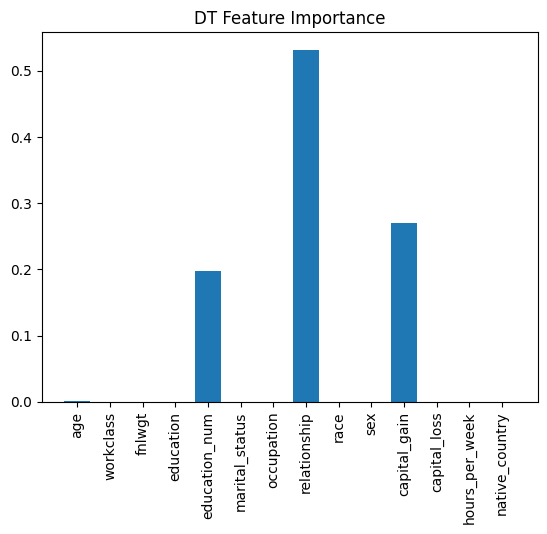

In [51]:
plt.figure()
plt.bar(X.columns, dt.feature_importances_)
plt.xticks(rotation=90)
plt.title("DT Feature Importance")
plt.show()

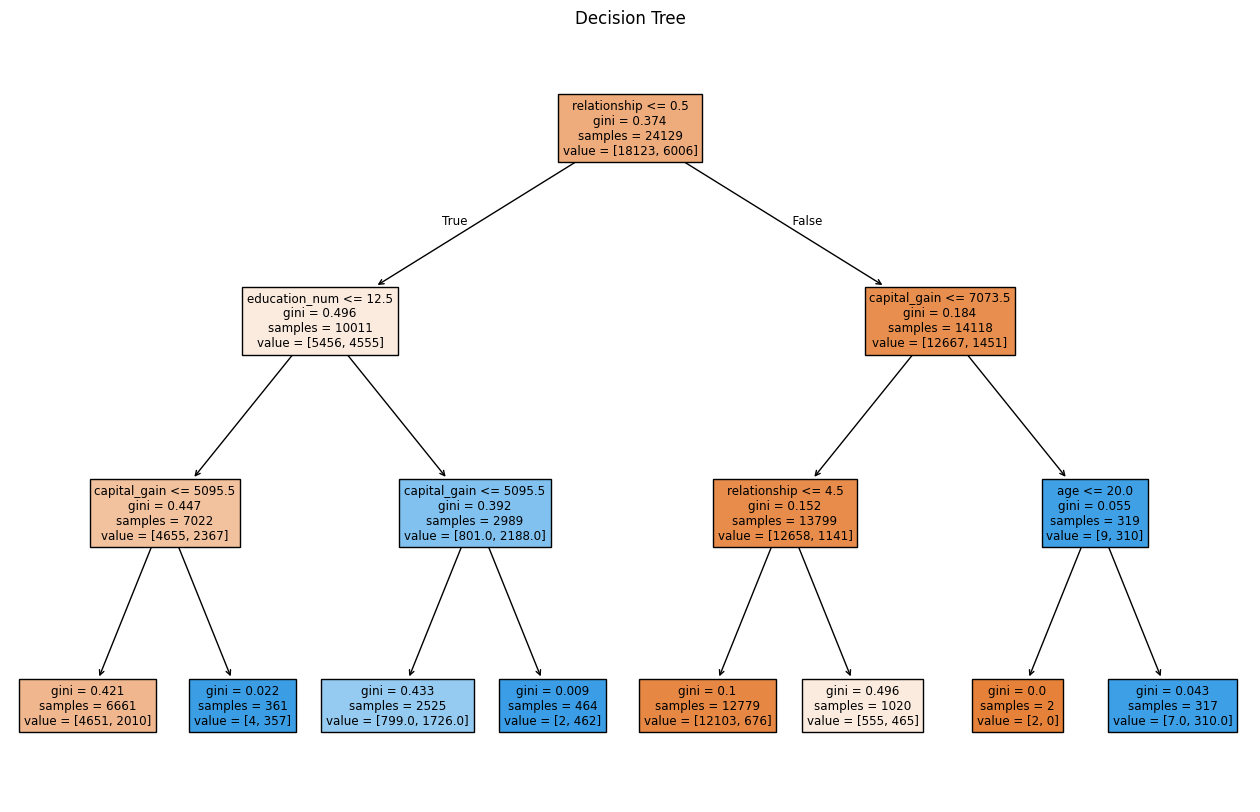

In [39]:
plt.figure(figsize=(16,10))
plot_tree(dt, feature_names=X.columns, filled=True)
plt.title("Decision Tree")
plt.show()

In [40]:
# random forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
classification_metrics(y_test, y_pred_rf)

{'Accuracy': 85.31, 'Precision': 79.28, 'Recall': 55.53, 'F1': 65.31}

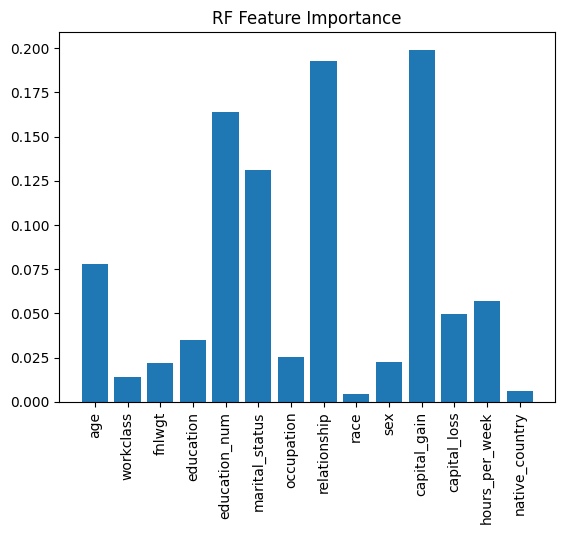

In [41]:
plt.figure()
plt.bar(X.columns, rf.feature_importances_)
plt.xticks(rotation=90)
plt.title("RF Feature Importance")
plt.show()

In [42]:
# gradient boosting
gb = GradientBoostingClassifier(n_estimators=100)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
classification_metrics(y_test, y_pred_gb)

{'Accuracy': 85.89, 'Precision': 78.38, 'Recall': 59.85, 'F1': 67.87}

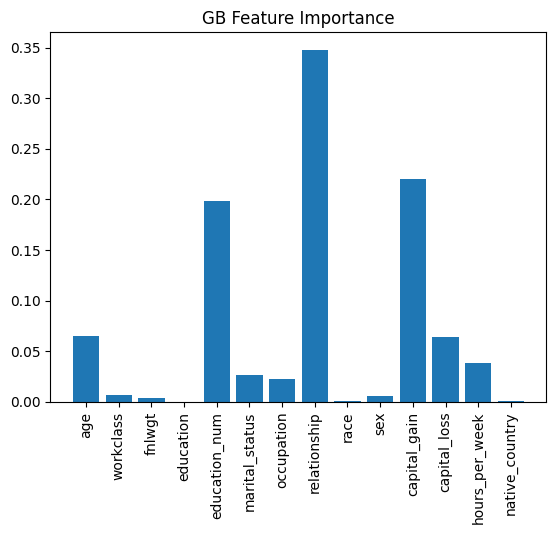

In [44]:
plt.figure()
plt.bar(X.columns, gb.feature_importances_)
plt.xticks(rotation=90)
plt.title("GB Feature Importance")
plt.show()

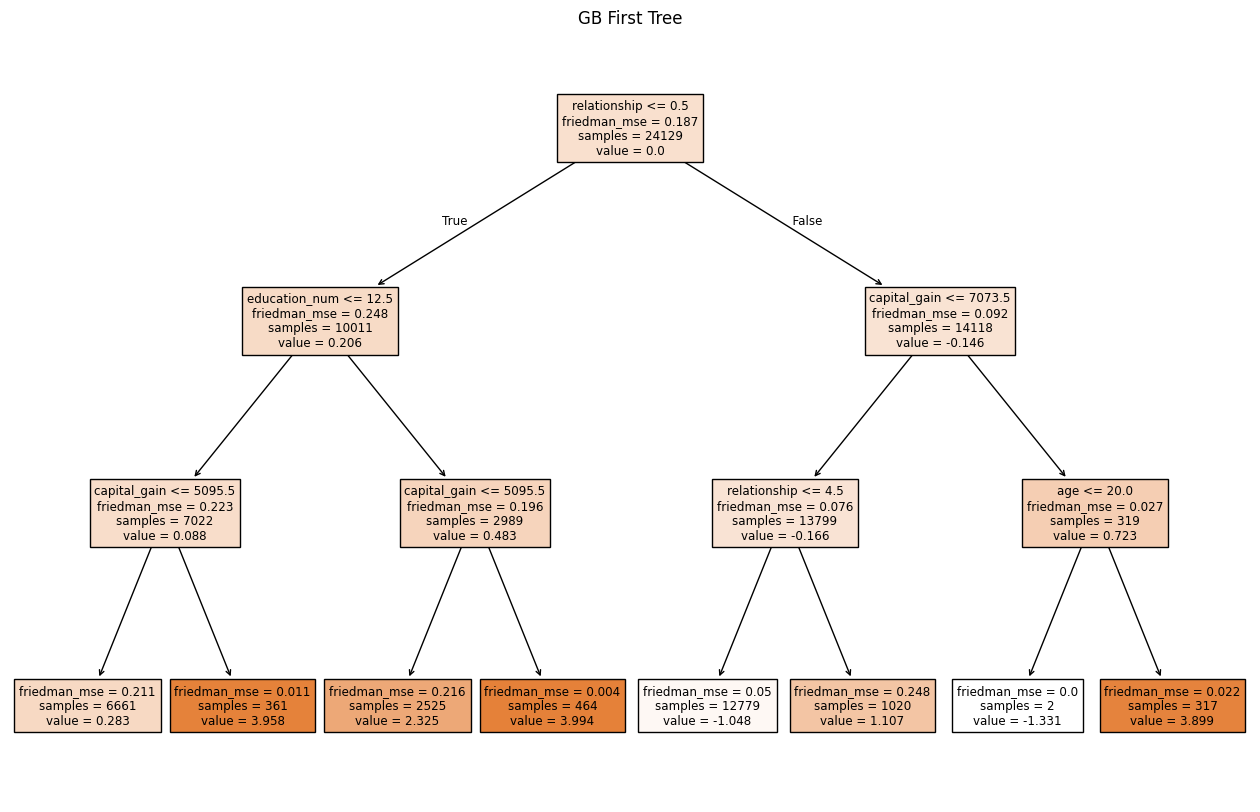

In [45]:
# visualize one tree
plt.figure(figsize=(16,10))
plot_tree(gb.estimators_[0,0], feature_names=X.columns, filled=True)
plt.title("GB First Tree")
plt.show()

In [47]:
# XGBoost
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, eval_metric="logloss")
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
classification_metrics(y_test, y_pred_xgb)

{'Accuracy': 86.44, 'Precision': 77.94, 'Recall': 63.52, 'F1': 69.99}

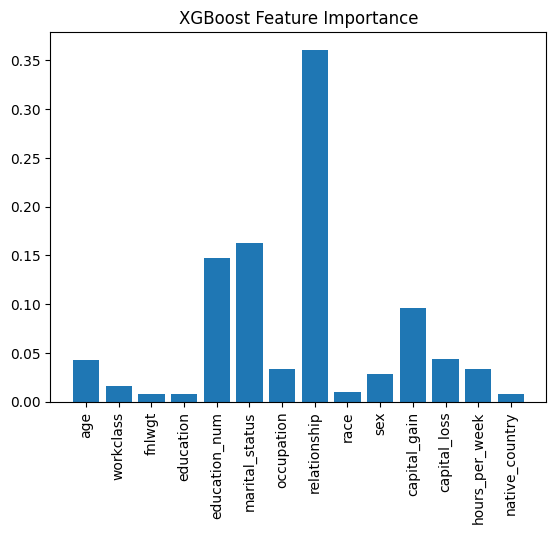

In [48]:
# Feature importance
plt.figure()
plt.bar(X.columns, xgb.feature_importances_)
plt.xticks(rotation=90)
plt.title("XGBoost Feature Importance")
plt.show()

<Figure size 4000x3000 with 0 Axes>

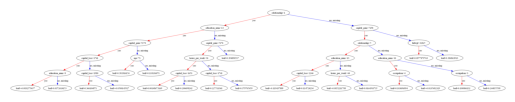

In [57]:
plt.figure(figsize=(40, 30))
xgboost.plot_tree(xgb, tree_idx=0) # plots the first tree at index 0
plt.show()

In [58]:
# saving to a file
dot = to_graphviz(xgb, tree_idx=0)
dot.render("xgboost_tree")

'xgboost_tree.pdf'

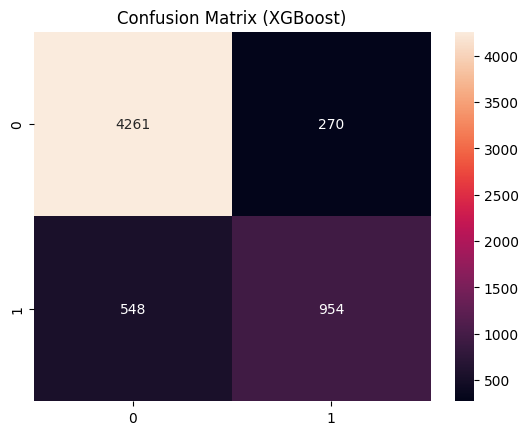

In [49]:
# best-performing model
best_pred = y_pred_xgb
cm = confusion_matrix(y_test, best_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (XGBoost)")
plt.show()

**Exercise**
1. Use cross-validation on the above problem. How does this affect performance if at all?
2. Select two models and perform hyperparameter optimization to select the best hyperparameters. How does this affect the performance of the models?
3. Choose a simple regression problem of your choice and use the above algorithms for prediction. Provide a comparison of their performance and their feature importance.